### Choice of the coils 

To select the loop detectors, the city is divided into rectangles and for each zone the detector closest to the rectangle centre is chosen. There are 100 zones in total, hence 100 detectors.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import os
import numpy as np
import pandas as pd
import seaborn as sns




df = pd.read_parquet('../data/processed/dataset_finale_2023-09-01_2025-09-30.parquet')
df.head()

DATA_INIZIO = '2023-09-01'
DATA_FINE   = '2025-09-30'

In [2]:
veicoli_medi_per_spira = (
    df.groupby(['chiave', 'data'])['conteggio_veicoli']
    .sum()
    .groupby('chiave')
    .mean()
    .rename("veicoli_medi")
)
# merge with the coordinates dataframe
df_mappa = df.merge(veicoli_medi_per_spira, on='chiave')

In [3]:
os.environ["BROWSER"] = "chrome" 
pio.renderers.default = "browser"

def map_coils(df):
    fig = px.scatter_map(
        df[['chiave', 'latitudine', 'longitudine','veicoli_medi']].drop_duplicates(subset='chiave'),
        lat="latitudine",
        lon="longitudine",
        hover_name="chiave",
        # size='veicoli_medi',
        zoom=11,
        height=600
    )

    fig.update_layout(
        mapbox_style="open-street-map",  # no token required
        margin={"r":0, "t":0, "l":0, "b":0}
    )

    fig.write_html("mappa.html")
map_coils(df_mappa)

### Coils accuracy management

Percentage of time in which accuracy is lower than 75% for each coil. 

In [4]:
df_mappa.chiave.unique()

array([ 41,  83, 106, 187, 201, 251, 432, 449, 505, 513, 525, 546, 600,
       683, 725, 760, 796, 833, 839, 843, 896])

In [5]:
drop_id = df.groupby('chiave')['accuratezza'].apply(lambda x: round((x > 50).sum()/len(x)*100, 2))
drop_id

chiave
41     42.04
83     93.56
106    77.35
187    95.95
201    98.65
251    42.44
432    97.97
449    90.33
505    92.09
513    97.27
525    96.80
546    97.42
600    97.38
683    97.68
725    79.94
760    97.84
796    81.94
833    86.67
839    97.45
843    97.68
896    97.90
Name: accuratezza, dtype: float64

Drop coils that have an accuracy lower than 50% for more than 75% of time considered. 

In [6]:
df = df[~df['chiave'].isin([41, 251])]

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 347016 entries, 18264 to 383543
Data columns (total 33 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   data                347016 non-null  str           
 1   id_uni              347016 non-null  int64         
 2   chiave              347016 non-null  int64         
 3   nome_via            347016 non-null  str           
 4   direzione           347016 non-null  str           
 5   longitudine         347016 non-null  float64       
 6   latitudine          347016 non-null  float64       
 7   fascia_oraria       347016 non-null  str           
 8   conteggio_veicoli   347016 non-null  int64         
 9   ora                 347016 non-null  int64         
 10  timestamp           347016 non-null  datetime64[us]
 11  temperature_2m      347016 non-null  float64       
 12  precipitation       347016 non-null  float64       
 13  rain                347016 non-null  floa

There are some days in which coils the coils are under maintenance. In those days, we find Nan values in dataset. We got 1784 nan values. 
It is necessary these values from dataset. 

In [8]:
df[df['accuratezza'].isna()]

,data,id_uni,chiave,nome_via,direzione,longitudine,latitudine,fascia_oraria,conteggio_veicoli,ora,...,data_str,festivo_nazionale,nome_festivita,festa_locale,evento_traffico,tipo_evento,impatto_evento,score_evento,eventi_sovrapposti,tipo_giorno
22618,2024-02-29,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,10_00_11_00,0,10,...,2024-02-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
22619,2024-02-29,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,11_00_12_00,0,11,...,2024-02-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
22620,2024-02-29,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,12_00_13_00,0,12,...,2024-02-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
23354,2024-03-31,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,02_00_03_00,0,2,...,2024-03-31,True,Pasqua,False,NaN,NaN,NaN,0,0,festivo
24599,2024-05-21,597,83,VIA ANDREA COSTA,O,11.311224,44.494098,23_00_24_00,0,23,...,2024-05-21,False,NaN,False,NaN,NaN,NaN,0,0,feriale
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382013,2025-07-29,117,896,VIALE GIAN BATTISTA ERCOLANI,S,11.357050,44.493602,05_00_06_00,0,5,...,2025-07-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
382014,2025-07-29,117,896,VIALE GIAN BATTISTA ERCOLANI,S,11.357050,44.493602,06_00_07_00,332,6,...,2025-07-29,False,NaN,False,NaN,NaN,NaN,0,0,feriale
382994,2025-09-08,117,896,VIALE GIAN BATTISTA ERCOLANI,S,11.357050,44.493602,02_00_03_00,44,2,...,2025-09-08,False,NaN,False,NaN,NaN,NaN,0,0,feriale
382995,2025-09-08,117,896,VIALE GIAN BATTISTA ERCOLANI,S,11.357050,44.493602,03_00_04_00,0,3,...,2025-09-08,False,NaN,False,NaN,NaN,NaN,0,0,feriale


In [9]:
df = df[df['accuratezza'].notna()]

In [10]:
def load_and_prepare(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["data"] = pd.to_datetime(df["data"])
    df["year"] = df["data"].dt.year
    df["week"] = df["data"].dt.isocalendar().week.astype(int)
    df["year_month"] = df["data"].dt.to_period("M")
    return df

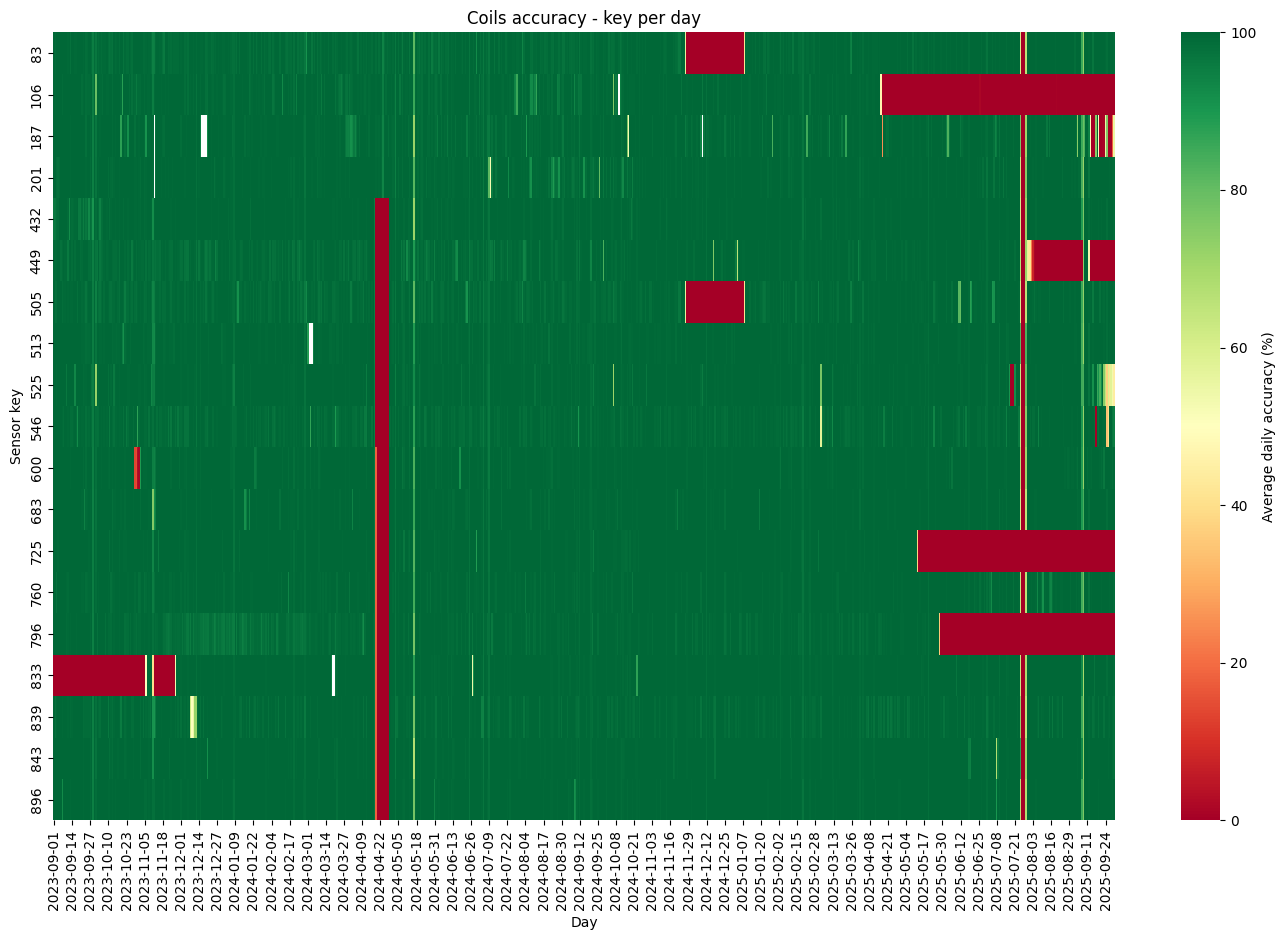

Anomalous sensor-days (|z_mod| > 3.5): 2715


,chiave,data,accuratezza,median_acc,MAD,modified_zscore
14394,896,2025-07-28,0.000000,100.000000,0.000000,-6.745000e+10
14393,896,2025-07-27,0.000000,100.000000,0.000000,-6.745000e+10
7847,600,2024-04-25,0.000000,100.000000,0.000000,-6.745000e+10
7846,600,2024-04-24,0.000000,100.000000,0.000000,-6.745000e+10
7848,600,2024-04-26,0.000000,100.000000,0.000000,-6.745000e+10
...,...,...,...,...,...,...
4796,505,2024-04-18,95.458333,99.291667,0.708333,-3.650235e+00
7079,546,2024-04-18,95.458333,99.291667,0.708333,-3.650235e+00
5137,505,2025-03-25,95.466667,99.291667,0.708333,-3.642300e+00
571,83,2025-03-25,95.466667,99.291667,0.708333,-3.642300e+00


In [11]:
acc_pivot = (
    df.assign(giorno=df['timestamp'].dt.date)
      .groupby(['chiave', 'giorno'])['accuratezza']
      .mean()
      .unstack()
)

fig, ax = plt.subplots(figsize=(14, max(2, len(acc_pivot) * 0.5)))
sns.heatmap(acc_pivot, cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Average daily accuracy (%)'}, ax=ax)
ax.set_title('Coils accuracy - key per day')
ax.set_xlabel('Day')
ax.set_ylabel('Sensor key')
plt.tight_layout()
plt.show()

# --- MAD-based residual deviation ---
MAD_THRESHOLD = 3.5  # standard threshold for modified z-score

acc_long = (
    acc_pivot.stack()
             .rename('accuratezza')
             .reset_index()
             .rename(columns={'giorno': 'data'})
)

# per-sensor median and MAD
sensor_stats = (
    acc_long.groupby('chiave')['accuratezza']
            .agg(median_acc='median',
                 MAD=lambda x: (x - x.median()).abs().median())
            .reset_index()
)

acc_long = acc_long.merge(sensor_stats, on='chiave')
acc_long['residual'] = acc_long['accuratezza'] - acc_long['median_acc']
# modified z-score (Iglewicz & Hoaglin 1993): 0.6745 * residual / MAD
acc_long['modified_zscore'] = 0.6745 * acc_long['residual'] / (acc_long['MAD'] + 1e-9)
acc_long['is_anomaly'] = acc_long['modified_zscore'].abs() > MAD_THRESHOLD

anomalies = acc_long[acc_long['is_anomaly']].sort_values('modified_zscore')
print(f"Anomalous sensor-days (|z_mod| > {MAD_THRESHOLD}): {len(anomalies)}")
anomalies[['chiave', 'data', 'accuratezza', 'median_acc', 'MAD', 'modified_zscore']]

How does traffic behave over the 24 hours of an average day, broken down by day of the week? How regular is the pattern? How much does it vary across detectors in the same category (e.g. two detectors both in the city centre)?

Is there a weekly seasonality (Mon–Fri vs Sat–Sun)? An annual seasonality (summer vs winter, August)? Do the two seasonalities interact?

How and to what extent does weather influence traffic? Does rain increase or decrease flows? The answer is not obvious and depends on the road.
How "noisy" are the data? Calculate the hour-by-hour standard deviation against the seasonal pattern: where do naturally undetected anomalies live?

What is the distribution of the accuracy dataset? How many detector-hours have accuracy below 100%? Below 50%? At 0%? These must be handled — you must decide how (exclude? impute? flag?).

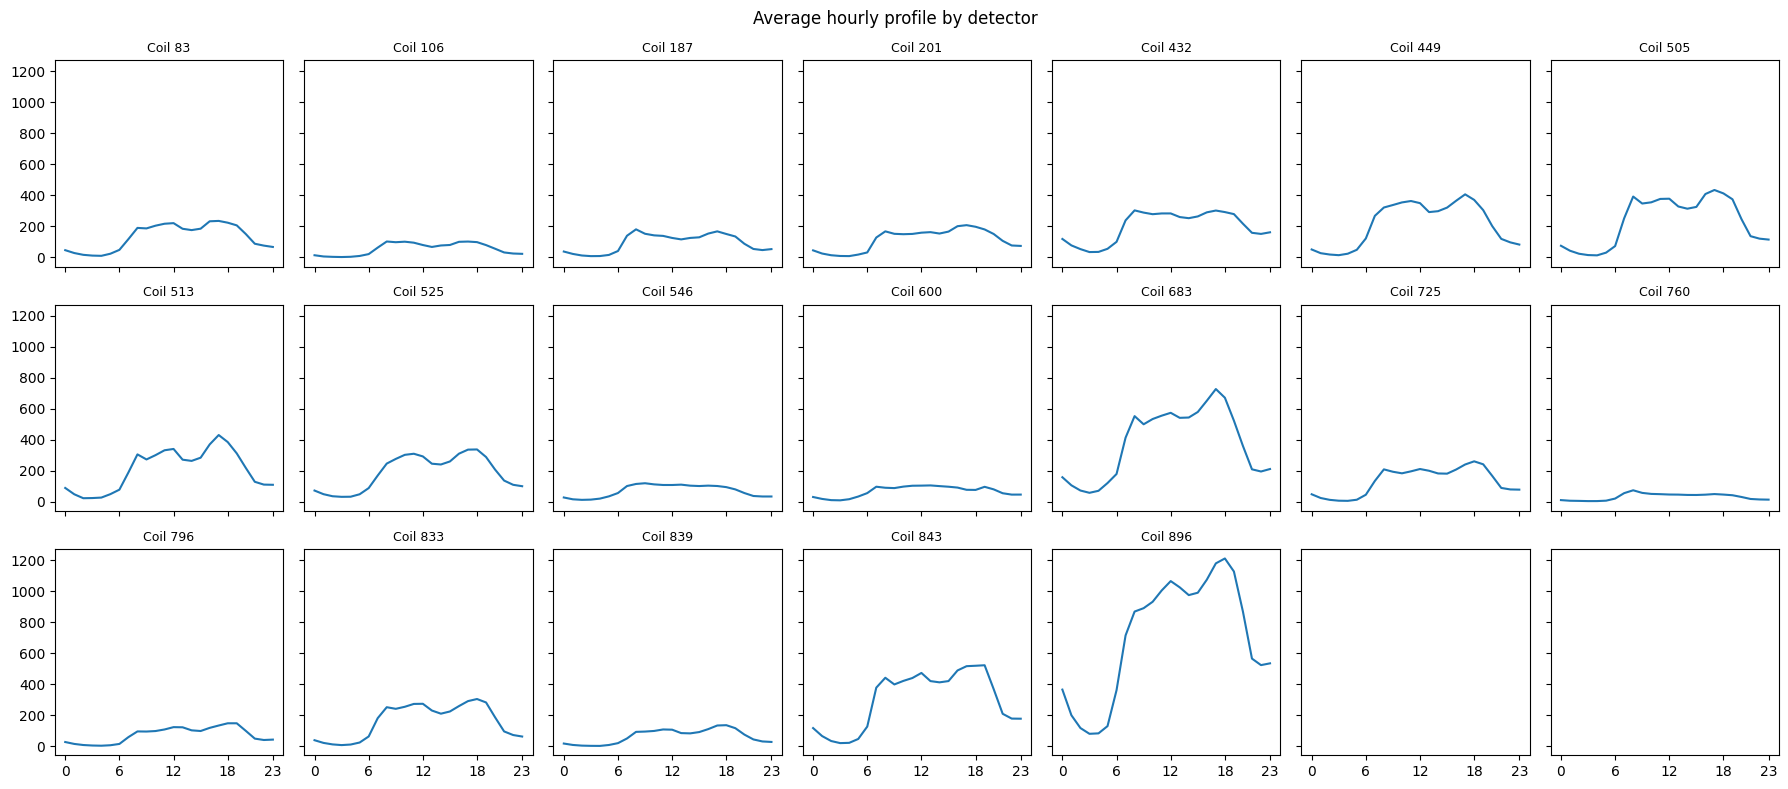

In [12]:
coil = sorted(df['chiave'].unique())

fig, axes = plt.subplots(3, 7, figsize=(18, 8), sharex=True, sharey=True)

for ax, coil in zip(axes.flatten(), coil):

    sub = (
        df[df['chiave'] == coil]
        .groupby('ora_del_giorno')['conteggio_veicoli']
        .mean()
        .reset_index()
    )

    ax.plot(sub['ora_del_giorno'], sub['conteggio_veicoli'])
    ax.set_title(f'Coil {coil}', fontsize=9)
    ax.set_xticks([0, 6, 12, 18, 23])

plt.suptitle('Average hourly profile by detector')
plt.tight_layout()
plt.show()

Let's make a comparison between two coils both located close to the city center, the 869 and 725, anche both close by each other. 

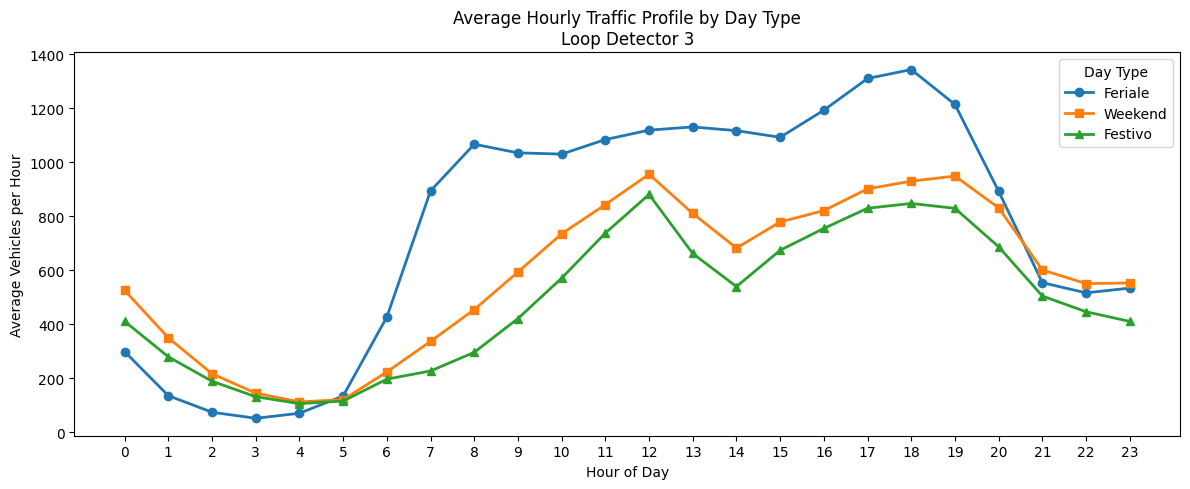

In [13]:
df_spira = df[df['chiave'] == 896]

profilo_g = (
    df_spira.groupby(['tipo_giorno', 'ora_del_giorno'])['conteggio_veicoli']
             .mean()
             .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for day_type, marker in zip(['feriale', 'weekend', 'festivo'], ['o', 's', '^']):
    subset = profilo_g[profilo_g['tipo_giorno'] == day_type]

    if not subset.empty:
        ax.plot(
            subset['ora_del_giorno'],
            subset['conteggio_veicoli'],
            marker=marker,
            linewidth=2,
            label=day_type.capitalize()
        )

ax.set_title(f'Average Hourly Traffic Profile by Day Type\nLoop Detector {3}')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Vehicles per Hour')
ax.set_xticks(range(24))
ax.legend(title='Day Type')

plt.tight_layout()
plt.show()

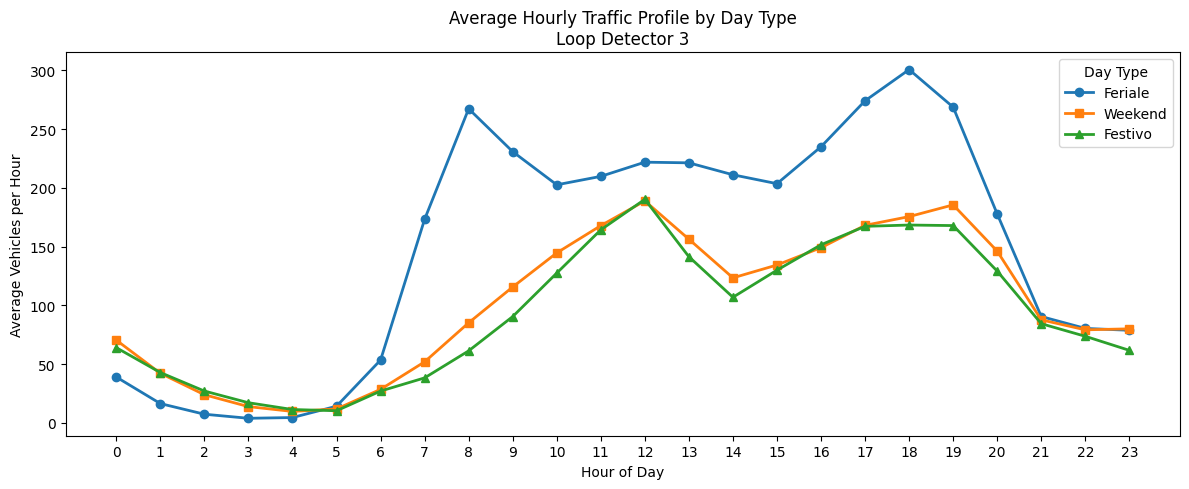

In [14]:
df_spira = df[df['chiave'] == 725]

profilo_g = (
    df_spira.groupby(['tipo_giorno', 'ora_del_giorno'])['conteggio_veicoli']
             .mean()
             .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for day_type, marker in zip(['feriale', 'weekend', 'festivo'], ['o', 's', '^']):
    subset = profilo_g[profilo_g['tipo_giorno'] == day_type]

    if not subset.empty:
        ax.plot(
            subset['ora_del_giorno'],
            subset['conteggio_veicoli'],
            marker=marker,
            linewidth=2,
            label=day_type.capitalize()
        )

ax.set_title(f'Average Hourly Traffic Profile by Day Type\nLoop Detector {3}')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Vehicles per Hour')
ax.set_xticks(range(24))
ax.legend(title='Day Type')

plt.tight_layout()
plt.show()

Let's see if there is a seasonal trend, a distinction between summer and winter. 

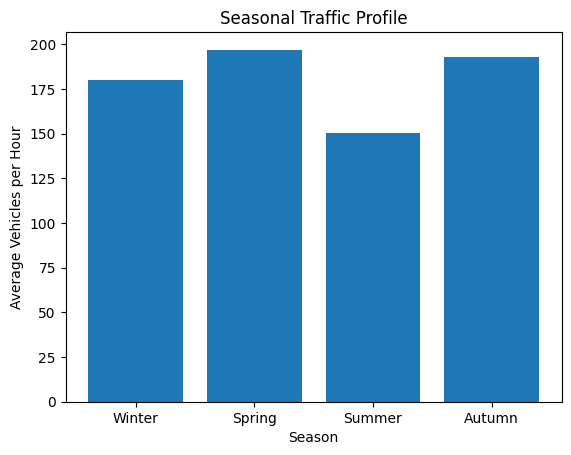

In [15]:
df['data'] = pd.to_datetime(df.data, format='%Y-%m-%d')
df['month'] = df['data'].dt.month

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

df['season'] = df['month'].map(season_map)
df

seasonal_profile = (
    df.groupby('season')['conteggio_veicoli']
            .mean()
            .reindex(['Winter', 'Spring', 'Summer', 'Autumn'])
)

plt.bar(seasonal_profile.index, seasonal_profile.values)
plt.title('Seasonal Traffic Profile')
plt.xlabel('Season')
plt.ylabel('Average Vehicles per Hour')
plt.show()

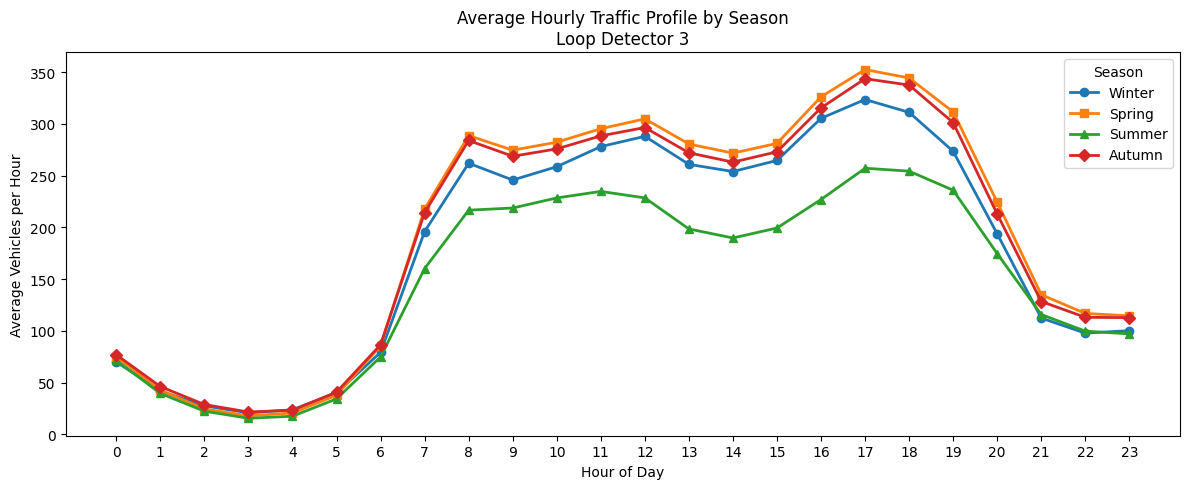

In [16]:
season_hour = (
    df.groupby(['season', 'ora_del_giorno'])['conteggio_veicoli']
            .mean()
            .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for season, marker in zip(['Winter', 'Spring', 'Summer', 'Autumn'], ['o', 's', '^', 'D']):
    subset = season_hour[season_hour['season'] == season]

    if not subset.empty:
        ax.plot(
            subset['ora_del_giorno'],
            subset['conteggio_veicoli'],
            marker=marker,
            linewidth=2,
            label=season.capitalize()
        )

ax.set_title(f'Average Hourly Traffic Profile by Season\nLoop Detector {3}')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Vehicles per Hour')
ax.set_xticks(range(24))
ax.legend(title='Season')

plt.tight_layout()
plt.show()

In [ ]:
#saving of the final file for the baselines notebook
eda_cols = ['season', 'month', 'weekday', 'precip_bin']
df.drop(columns=[c for c in eda_cols if c in df.columns], inplace=True)

df.to_parquet(f'../data/processed/dataset_finale_{DATA_INIZIO}_{DATA_FINE}.parquet', index=False)